Important Libraries

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn import metrics
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk
import joblib

NLTK downloads

In [2]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\al_sh\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\al_sh\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\al_sh\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Load and Filter Dataset

In [3]:
df = pd.read_csv('drugsComTrain_raw.csv', on_bad_lines='skip', sep=',', engine='python')
conditions_of_interest = ['Bacterial Infection', 'Depression', 'Diabetes, Type 2', 'High Blood Pressure', 'Migraine']
df_train = df[df['condition'].isin(conditions_of_interest)]


Word Cloud 

In [4]:
def generate_wordcloud(data, title):
    wc = WordCloud(max_words=500, width=1600, height=800).generate(" ".join(data))
    plt.figure(figsize=(10, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=14)
    plt.show()

Generate Word Clouds for each Disease

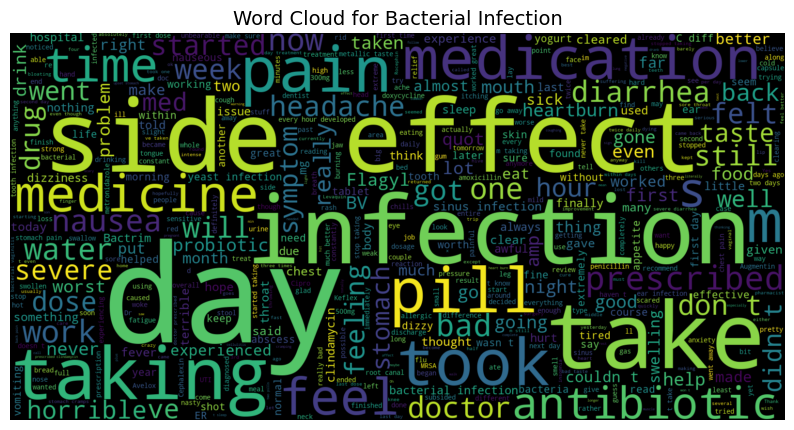

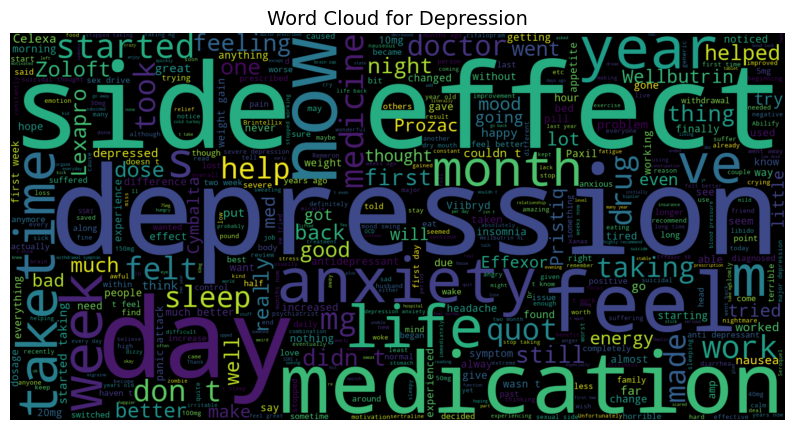

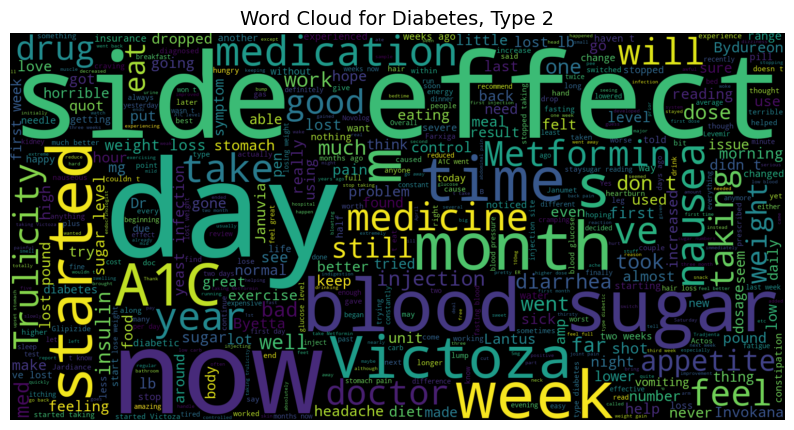

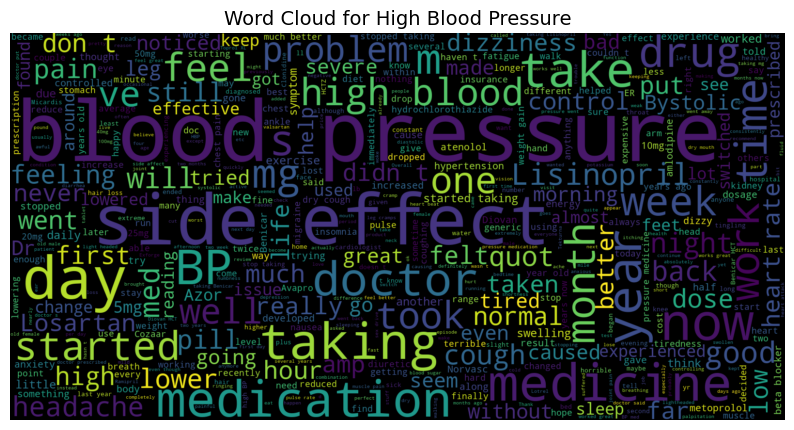

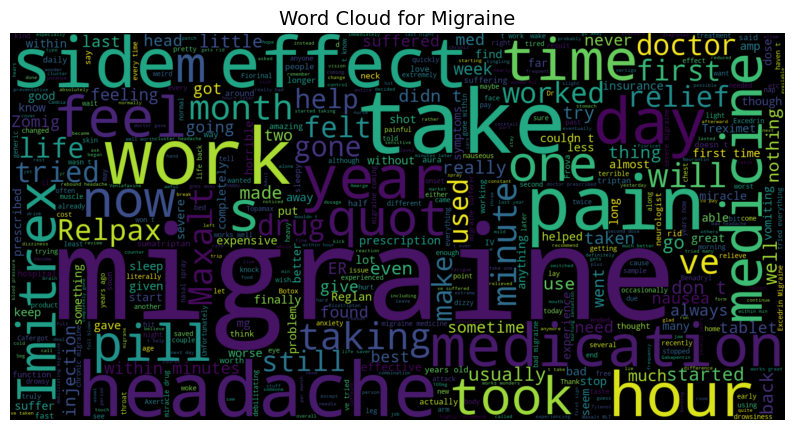

In [5]:
for condition in conditions_of_interest:
    generate_wordcloud(df_train[df_train['condition'] == condition]['review'], f"Word Cloud for {condition}")


Processing Functions

In [6]:
lemmatizer = WordNetLemmatizer()
stop = set(stopwords.words('english'))


In [7]:
import re
from bs4 import BeautifulSoup

def review_to_words(raw_review):
    review_text = BeautifulSoup(raw_review, 'html.parser').get_text()
    letters_only = re.sub('[^a-zA-Z]', ' ', review_text)
    words = letters_only.lower().split()
    meaningful_words = [lemmatizer.lemmatize(w) for w in words if w not in stop]
    return ' '.join(meaningful_words)


Apply Preprocessing

In [8]:
df_train['review_clean'] = df_train['review'].apply(review_to_words)


C:\Users\al_sh\AppData\Local\Temp\ipykernel_15092\517952700.py:5: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  review_text = BeautifulSoup(raw_review, 'html.parser').get_text()
C:\Users\al_sh\AppData\Local\Temp\ipykernel_15092\2779621622.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train['review_clean'] = df_train['review'].apply(review_to_words)


Split Data

In [9]:
X = df_train['review_clean']
Y = df_train['condition']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, stratify=Y, test_size=0.2, random_state=42)


TF-IDF Vectorizer

In [10]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.8, ngram_range=(1, 3))
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


Passive Aggressive Classifier

In [11]:
passive_model = PassiveAggressiveClassifier()
passive_model.fit(X_train_tfidf, Y_train)

PassiveAggressiveClassifier()

Evaluate the Model

In [12]:
pred = passive_model.predict(X_test_tfidf)
accuracy = metrics.accuracy_score(Y_test, pred)
print(f"Accuracy: {accuracy:.3f}")


Accuracy: 0.961


Confusion Matrix

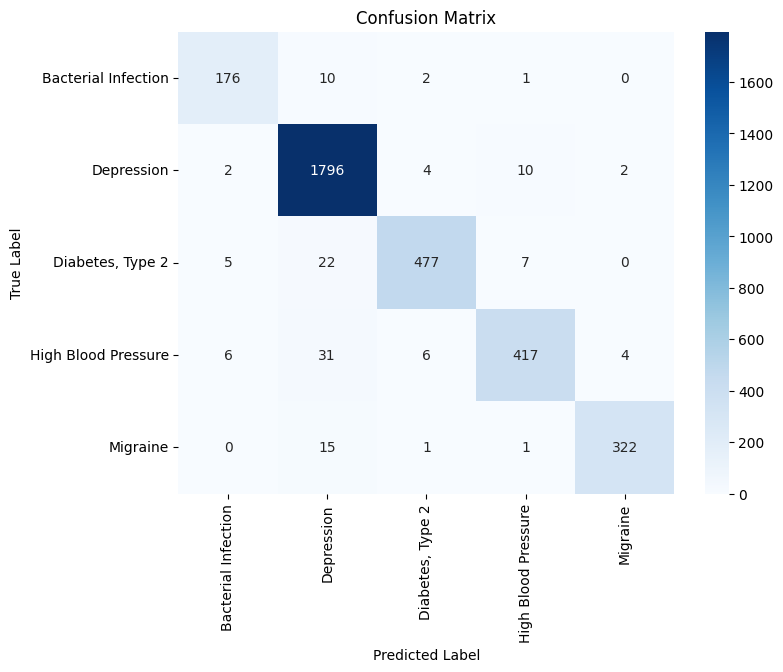

In [14]:
cm = metrics.confusion_matrix(Y_test, pred, labels=conditions_of_interest)

def plot_confusion_matrix(cm, classes, title='Confusion Matrix'):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

plot_confusion_matrix(cm, conditions_of_interest)


Save Model and Vectorizer

In [15]:
joblib.dump(tfidf_vectorizer, 'tfidfvectorizer.pk1')
joblib.dump(passive_model, 'passmodel.pk1')


['passmodel.pk1']

Example Prediction

In [ ]:

example_text = ["one week eight week later still suffering foot heel pain however going back vasotec blood sugar dropped back"]
example_tfidf = tfidf_vectorizer.transform(example_text)
example_pred = passive_model.predict(example_tfidf)[0]
print(f"Predicted Condition: {example_pred}")
